In [1]:
# =====================================
# === Block 1: Import Libraries
# =====================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time
import joblib
from collections import Counter

from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,
    confusion_matrix
)
from sklearn.preprocessing import label_binarize
from imblearn.under_sampling import RandomUnderSampler

print("✅ Libraries loaded successfully!")

✅ Libraries loaded successfully!


In [2]:
# =====================================
# === Block 2: Load Dataset
# =====================================
train_path = "/content/drive/MyDrive/Senior_Project/dataset/PM2.5 dataset/train_split.csv"
test_path  = "/content/drive/MyDrive/Senior_Project/dataset/PM2.5 dataset/test_split.csv"

df_train = pd.read_csv(train_path)
df_test  = pd.read_csv(test_path)

print("Training shape:", df_train.shape)
print("Testing shape :", df_test.shape)
df_train.head()

Training shape: (329623, 13)
Testing shape : (82406, 13)


,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,WSPM,wd_sin,wd_cos,PM2.5_level
0,0.140,0.045,0.280,0.184,0.068,0.462,0.578,0.389,0.000,0.136,0.146,0.146,5
1,0.031,0.003,0.021,0.102,0.206,0.667,0.185,0.876,0.031,0.083,0.500,1.000,3
2,0.071,0.055,0.142,0.122,0.022,0.291,0.606,0.385,0.000,0.098,0.854,0.854,2
3,0.070,0.003,0.003,0.020,0.180,0.533,0.368,0.393,0.000,0.159,0.038,0.691,2
4,0.087,0.005,0.311,0.163,0.042,0.665,0.351,0.852,0.000,0.008,0.854,0.146,4


In [3]:
# =====================================
# === Block 3: Split Features/Target
# =====================================
X_train = df_train.drop("PM2.5_level", axis=1)
y_train = df_train["PM2.5_level"]

X_test = df_test.drop("PM2.5_level", axis=1)
y_test = df_test["PM2.5_level"]

print("\nClass distribution (Train):", Counter(y_train))
print("Class distribution (Test):", Counter(y_test))


Class distribution (Train): Counter({5: 128801, 4: 73062, 1: 64314, 2: 33504, 3: 29942})
Class distribution (Test): Counter({5: 32201, 4: 18265, 1: 16078, 2: 8376, 3: 7486})


In [4]:
# =====================================
# === Block 4: Auto RandomUnderSampler (Smart Reduction Strategy)
# =====================================
from collections import Counter
import numpy as np
from imblearn.under_sampling import RandomUnderSampler

# --- ดู distribution ก่อนลด ---
class_counts = Counter(y_train)
print("\nBefore UnderSampling:", class_counts)

# --- คำนวณค่ามัธยฐานและจำนวนสูงสุด ---
median_count = np.median(list(class_counts.values()))
max_count = max(class_counts.values())

# --- สร้างอัตราการลดแบบอัตโนมัติ ---
# คลาสใหญ่จะถูกลดมาก คลาสใกล้ median ลดน้อย
max_reduction = 0.5  # ✅ ลดสูงสุดไม่เกิน 50% (ปรับได้ตามต้องการ)
sampling_strategy = {}

for cls, count in class_counts.items():
    if count > median_count:
        ratio = 1 - max_reduction * ((count - median_count) / (max_count - median_count))
        new_count = int(count * ratio)
        sampling_strategy[cls] = new_count
    else:
        sampling_strategy[cls] = count  # ไม่ลดคลาสเล็ก

print("\nAuto Sampling Strategy:", sampling_strategy)

# --- ใช้ RandomUnderSampler ตามกลยุทธ์ที่คำนวณได้ ---
rus = RandomUnderSampler(sampling_strategy=sampling_strategy, random_state=42)
X_resampled, y_resampled = rus.fit_resample(X_train, y_train)

print("After UnderSampling :", Counter(y_resampled))


Before UnderSampling: Counter({5: 128801, 4: 73062, 1: 64314, 2: 33504, 3: 29942})

Auto Sampling Strategy: {5: 64400, 3: 29942, 2: 33504, 4: 68106, 1: 64314}
After UnderSampling : Counter({4: 68106, 5: 64400, 1: 64314, 2: 33504, 3: 29942})


In [5]:
# =====================================
# === Block 5: 10-Fold Cross Validation (Train) + Mean ± SD
# =====================================
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.preprocessing import label_binarize
from sklearn.model_selection import StratifiedKFold
import pandas as pd
import numpy as np
import time
import os

print("\n=== 10-Fold Cross Validation Results ===")
kfold = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

accuracy_list, precision_list, recall_list, f1_list, auc_scores = [], [], [], [], []
start_time = time.time()

for fold, (train_idx, val_idx) in enumerate(kfold.split(X_resampled, y_resampled), 1):
    X_tr, X_val = X_resampled.iloc[train_idx], X_resampled.iloc[val_idx]
    y_tr, y_val = y_resampled.iloc[train_idx], y_resampled.iloc[val_idx]

    model = KNeighborsClassifier()
    model.fit(X_tr, y_tr)
    y_pred = model.predict(X_val)

    acc = accuracy_score(y_val, y_pred)
    prec = precision_score(y_val, y_pred, average='weighted', zero_division=0)
    rec = recall_score(y_val, y_pred, average='weighted', zero_division=0)
    f1 = f1_score(y_val, y_pred, average='weighted')

    y_val_bin = label_binarize(y_val, classes=np.unique(y_resampled))
    y_pred_bin = label_binarize(y_pred, classes=np.unique(y_resampled))
    auc_score = roc_auc_score(y_val_bin, y_pred_bin, average='macro')

    accuracy_list.append(acc)
    precision_list.append(prec)
    recall_list.append(rec)
    f1_list.append(f1)
    auc_scores.append(auc_score)

# ✅ สรุปผลเป็น DataFrame
cv_df = pd.DataFrame({
    "Fold": range(1, 11),
    "Accuracy": accuracy_list,
    "Precision": precision_list,
    "Recall": recall_list,
    "F1": f1_list,
    "AUC_ROC": auc_scores
})
print(cv_df.round(6))

# ✅ ค่าเฉลี่ย + ส่วนเบี่ยงเบนมาตรฐาน (Mean ± SD)
acc_mean, acc_sd = np.mean(accuracy_list), np.std(accuracy_list)
prec_mean, prec_sd = np.mean(precision_list), np.std(precision_list)
rec_mean, rec_sd = np.mean(recall_list), np.std(recall_list)
f1_mean, f1_sd = np.mean(f1_list), np.std(f1_list)
auc_mean, auc_sd = np.mean(auc_scores), np.std(auc_scores)

print("\n📊 Cross-validation (10 folds) Metrics (Mean ± SD):")
print(f"Accuracy : {acc_mean:.3f} ± {acc_sd:.3f}")
print(f"Precision: {prec_mean:.3f} ± {prec_sd:.3f}")
print(f"Recall   : {rec_mean:.3f} ± {rec_sd:.3f}")
print(f"F1-score : {f1_mean:.3f} ± {f1_sd:.3f}")
print(f"AUC-ROC  : {auc_mean:.3f} ± {auc_sd:.3f}")

end_time = time.time()
print(f"\n⏱ Completed in {end_time - start_time:.2f} seconds")




=== 10-Fold Cross Validation Results ===
   Fold  Accuracy  Precision    Recall        F1   AUC_ROC
0     1  0.683252   0.675005  0.683252  0.677152  0.768356
1     2  0.681715   0.674460  0.681715  0.676139  0.767725
2     3  0.689054   0.681484  0.689054  0.683518  0.772865
3     4  0.685942   0.679531  0.685942  0.680785  0.770517
4     5  0.681600   0.675418  0.681600  0.676793  0.768505
5     6  0.683406   0.675540  0.683406  0.677504  0.768495
6     7  0.685545   0.677111  0.685545  0.679206  0.769505
7     8  0.683432   0.675957  0.683432  0.677932  0.768592
8     9  0.684661   0.677258  0.684661  0.678967  0.769492
9    10  0.684585   0.677720  0.684585  0.679263  0.769356

📊 Cross-validation (10 folds) Metrics (Mean ± SD):
Accuracy : 0.684 ± 0.002
Precision: 0.677 ± 0.002
Recall   : 0.684 ± 0.002
F1-score : 0.679 ± 0.002
AUC-ROC  : 0.769 ± 0.001

⏱ Completed in 127.48 seconds


In [6]:
# 💾 (Optional) บันทึก mean+sd ลงไฟล์ CSV
cv_summary = pd.DataFrame([{
    "Accuracy_mean": acc_mean, "Accuracy_sd": acc_sd,
    "Precision_mean": prec_mean, "Precision_sd": prec_sd,
    "Recall_mean": rec_mean, "Recall_sd": rec_sd,
    "F1_mean": f1_mean, "F1_sd": f1_sd,
    "AUC_mean": auc_mean, "AUC_sd": auc_sd
}])

base_path = '/content/drive/MyDrive/Senior_Project/roc/KNN_Roc/all/MeanSD/'
summary_path = base_path + "KNN_randomunder_CV_MeanSD.csv"

# ✅ ตรวจสอบและสร้างโฟลเดอร์ก่อนบันทึก (กัน error)
os.makedirs(base_path, exist_ok=True)

cv_summary.to_csv(summary_path, index=False)
print(f"💾 Mean + SD summary saved to {summary_path}")

💾 Mean + SD summary saved to /content/drive/MyDrive/Senior_Project/roc/KNN_Roc/all/MeanSD/KNN_randomunder_CV_MeanSD.csv


In [7]:
# =====================================
# === Block 6: Train on Full Training Set
# =====================================
model = KNeighborsClassifier()
model.fit(X_resampled, y_resampled)
print("✅ Final KNN model trained successfully.")

✅ Final KNN model trained successfully.


In [8]:
# =====================================
# === Block 7: Evaluate on Test Set
# =====================================
from sklearn.metrics import classification_report, roc_auc_score

y_pred_test = model.predict(X_test)
y_pred_proba_test = model.predict_proba(X_test)

acc_test = accuracy_score(y_test, y_pred_test)
prec_test = precision_score(y_test, y_pred_test, average='weighted', zero_division=0)
rec_test = recall_score(y_test, y_pred_test, average='weighted', zero_division=0)
f1_test = f1_score(y_test, y_pred_test, average='weighted')

# Binarize for AUC (One-vs-Rest)
y_test_bin = label_binarize(y_test, classes=np.unique(y_resampled))
auc_test = roc_auc_score(y_test_bin, y_pred_proba_test, average='macro')

print("\n📈 Test Set Metrics:")
print(f"Accuracy: {acc_test:.3f}, Precision: {prec_test:.3f}, Recall: {rec_test:.3f}, F1: {f1_test:.3f}, AUC: {auc_test:.3f}")

# ✅ Classification Report
print("\nClassification Report:")
print(classification_report(y_test, y_pred_test))


📈 Test Set Metrics:
Accuracy: 0.715, Precision: 0.722, Recall: 0.715, F1: 0.715, AUC: 0.883

Classification Report:
              precision    recall  f1-score   support

           1       0.74      0.86      0.80     16078
           2       0.42      0.38      0.40      8376
           3       0.40      0.35      0.37      7486
           4       0.61      0.71      0.65     18265
           5       0.93      0.82      0.87     32201

    accuracy                           0.71     82406
   macro avg       0.62      0.62      0.62     82406
weighted avg       0.72      0.71      0.71     82406



Confusion Matrix:
[[13823  1635   341   233    46]
 [ 3284  3186  1198   689    19]
 [  959  1770  2618  2050    89]
 [  474   909  2093 12985  1804]
 [   64   100   305  5462 26270]]


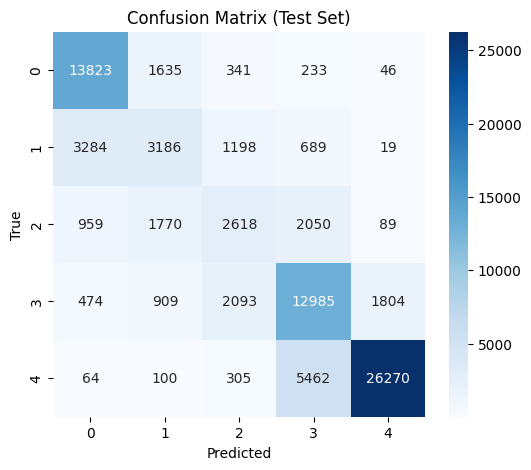

In [9]:
# =====================================
# === Block 8: Confusion Matrix
# =====================================
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred_test)
print("Confusion Matrix:")
print(cm)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix (Test Set)")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()



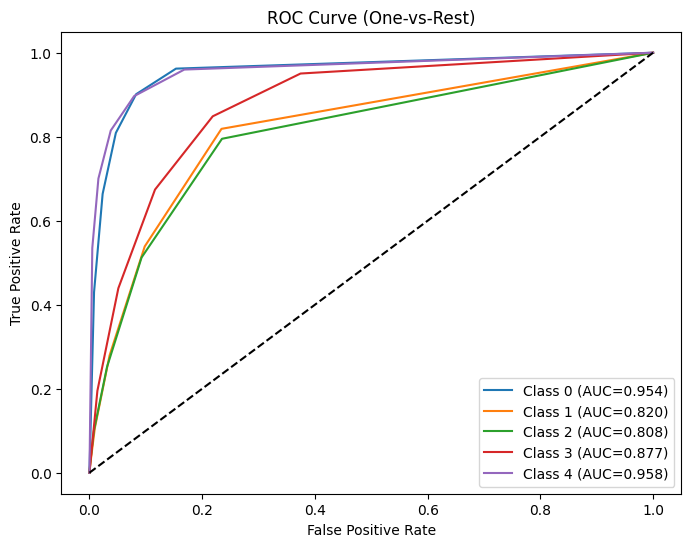

In [10]:
# =====================================
# === Block 9: ROC Curve (Per-Class)
# =====================================
from sklearn.metrics import roc_curve, auc

y_test_bin = label_binarize(y_test, classes=np.unique(y_resampled))
y_pred_proba_test = model.predict_proba(X_test)

classes = np.unique(y_resampled)
n_classes = len(classes)

fpr, tpr, roc_auc = {}, {}, {}
for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_pred_proba_test[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

plt.figure(figsize=(8,6))
for i in range(n_classes):
    plt.plot(fpr[i], tpr[i], label=f"Class {i} (AUC={roc_auc[i]:.3f})")
plt.plot([0,1],[0,1],'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve (One-vs-Rest)")
plt.legend()
plt.show()

In [ ]:
# =====================================
# === Block 10: Save ROC Data (Mean ROC Curve)
# =====================================
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

classes = [0, 1, 2, 3, 4]
y_test_bin = label_binarize(y_test, classes=classes)
y_pred_proba_test = model.predict_proba(X_test)
n_classes = y_test_bin.shape[1]

fpr = {}
tpr = {}
roc_auc = {}

for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_pred_proba_test[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

all_fpr = np.unique(np.concatenate([fpr[i] for i in range(n_classes)]))
mean_tpr = np.zeros_like(all_fpr)

for i in range(n_classes):
    mean_tpr += np.interp(all_fpr, fpr[i], tpr[i])

mean_tpr /= n_classes
macro_roc_auc = auc(all_fpr, mean_tpr)

roc_df = pd.DataFrame({'fpr': all_fpr, 'tpr': mean_tpr})
roc_df.to_csv("/content/drive/MyDrive/Senior_Project/roc/randomunder/roc_data_KNN_randomunder.csv", index=False)

print(f"Macro AUC = {macro_roc_auc:.4f}")
print(roc_df.head())


Macro AUC = nan
        fpr  tpr
0  0.000000  NaN
1  0.003080  NaN
2  0.003603  NaN
3  0.014710  NaN
4  0.018635  NaN


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:1188: UndefinedMetricWarning: No positive samples in y_true, true positive value should be meaningless
  warnings.warn(


In [ ]:
# =====================================
# === Save Model, AUC & ROC Data
# =====================================
from google.colab import drive
drive.mount('/content/drive')

base_path = '/content/drive/MyDrive/Senior_Project/roc/randomunder/'

# --- Save Model ---
joblib.dump(model, base_path + 'knn_randomunder.pkl')
print(f"\n💾 Model saved as {base_path}knn_randomunder.pkl")

# --- Save AUC per Fold + Test ---
auc_csv = pd.DataFrame({
    "Fold": list(range(1, 11)) + ["Test Set"],
    "AUC_ROC": auc_scores + [auc_test]
})
auc_csv.to_csv(base_path + 'knn_randomunder_auc.csv', index=False)
print(f"💾 AUC-ROC values saved to {base_path}knn_randomunder_auc.csv")

# === คำนวณ ROC Curve ด้วย predict_proba ===
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc
import numpy as np
import pandas as pd

# ใช้คลาสจากโมเดลจริง
classes = model.classes_
n_classes = len(classes)

# แปลง y_test เป็น one-hot ตาม classes
y_test_bin = label_binarize(y_test, classes=classes)

# ใช้ค่า predict_proba จากโมเดล KNN
y_pred_proba_test = model.predict_proba(X_test)

# คำนวณ ROC curve สำหรับแต่ละคลาส
fpr, tpr, roc_auc = {}, {}, {}
for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_pred_proba_test[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# === (Optional) คำนวณ Macro-average ROC ===
all_fpr = np.unique(np.concatenate([fpr[i] for i in range(n_classes)]))
mean_tpr = np.zeros_like(all_fpr)
for i in range(n_classes):
    mean_tpr += np.interp(all_fpr, fpr[i], tpr[i])
mean_tpr /= n_classes
macro_auc = auc(all_fpr, mean_tpr)

# === รวม ROC Points ===
roc_points = []
for i in range(n_classes):
    for fp, tp in zip(fpr[i], tpr[i]):
        roc_points.append({'Class': i, 'FPR': fp, 'TPR': tp})

# === Save FPR & TPR สำหรับแต่ละคลาส ===
roc_df = pd.DataFrame(roc_points)
roc_df.to_csv(base_path + 'knn_randomunder_roc_points.csv', index=False)
print(f"💾 ROC points saved to {base_path}knn_randomunder_roc_points.csv")

print(f"\n✅ Macro AUC = {macro_auc:.4f}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).

💾 Model saved as /content/drive/MyDrive/Senior_Project/roc/randomunder/knn_randomunder.pkl
💾 AUC-ROC values saved to /content/drive/MyDrive/Senior_Project/roc/randomunder/knn_randomunder_auc.csv
💾 ROC points saved to /content/drive/MyDrive/Senior_Project/roc/randomunder/knn_randomunder_roc_points.csv

✅ Macro AUC = 0.8835
